> **Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Junho de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# Aula 01 - Polinômios de Jacobi e suas Derivadas

Na formulação Galerkin Descontínuo (DG) representamos a solução numérica dentro de cada elemento usando uma combinação linear de funções de base.

Se usássemos polinômios comuns ($1, x, x^2, x^3...$), as nossas matrizes (Massa, Rigidez) ficariam severamente mal condicionadas em altas ordens. A solução matemática para isso é utilizar **Polinômios Ortogonais**, que derivam do problema de Sturm-Liouville.





## O Problema de Sturm-Liouville
O problema de Sturm-Liouville não é uma equação específica, mas uma **classe de equações diferenciais lineares de segunda ordem** com o seguinte formato:

$$-\frac{d}{dx}\left[p(x)\frac{dy}{dx}\right]+q(x)y=\lambda w(x)y$$

A grande genialidade desse teorema é a propriedade:

> **se uma equação diferencial puder ser escrita nesse formato, suas soluções (as autofunções $y_n$) são matematicamente garantidas como ortogonais**

em um dado intervalo, sendo "pesadas" pela função $w(x)$ (a função peso).

A forma de escrever/verificar isso matematicamente é pela seguinte integral (em um intervalo padrão):

$$\int_{-1}^1 w(x) y_m(x)y_n(x) = \delta_{mn}$$

em que $\delta_{mn}$ é a função **delta de Kronecker** definida por
$$\delta_{mn} = \begin{cases}
1, & \text{se } m = n \\
0, & \text{se } m \neq n
\end{cases}$$


É exatamente essa ortogonalidade que garante que nossas matrizes no DG fiquem fáceis de inverter!


## O Polinômio de Jacobi

Os **Polinômio de Jacobi** ($y = \mathcal{P}_{k}^{\alpha,\beta}$) nascem da Equação Diferencial Ordinária (EDO) de Jacobi, tal EDO se encaixa perfeitamente no molde do problema de Sturm-Liouville, sendo escrita da forma:

$$(1-x^2)y'' + [\beta - \alpha - (\alpha + \beta + 2)x]y' + k(k + \alpha + \beta + 1)y = 0$$

Ao olhar para Sturm-Liouville os valores de $p(x)$ e $q(x)$ são:
* $p(x) = (1-x)^{\alpha+1}(1+x)^{\beta+1}$
* $q(x) = 0$

o autovalor $\lambda$ (que varia de acordo com o grau $k$ do polinômio) é dado por:
* $\lambda_k = k(k + \alpha + \beta + 1)$

e a função peso:
* $w(x) = (1-x)^\alpha(1+x)^\beta$.

Com parâmetros específicos, podemos obter famílias de polinômios famosas, como os:
* **Polinômios de Legendre:** $\alpha=0$, $\beta=0 \implies w(x)=1$ (Os que usaremos!)
* **Polinômios de Chebyshev:** $\alpha=-\frac{1}{2}$, $\beta=-\frac{1}{2} \implies w(x)= \frac{1}{\sqrt{1-x^2}}$

#### Demonstração: Da EDO de Jacobi a Sturm-Liouville

<details>
<summary>Clique aqui para ver a demonstração matemática</summary>

A Equação Diferencial Ordinária (EDO) clássica que define a família de polinômios de Jacobi é dada por:

$$(1-\xi^2)y'' + [\beta - \alpha - (\alpha + \beta + 2)\xi]y' + k(k + \alpha + \beta + 1)y = 0$$

À primeira vista, ela não se parece com o formato de **Sturm-Liouville**:
$$-\frac{d}{d\xi}\left[p(\xi)\frac{dy}{d\xi}\right] + q(\xi)y = \lambda w(\xi)y$$

O "truque" analítico que destrava as propriedades ortogonais e a **Fórmula de Rodrigues** é multiplicar a EDO inteira pela nossa função peso $w(\xi) = (1-\xi)^\alpha(1+\xi)^\beta$. Ao fazer isso, a equação se torna:

$$\underbrace{(1-\xi^2)w(\xi)}_{p(\xi)}y'' + \underbrace{w(\xi)[\beta - \alpha - (\alpha + \beta + 2)\xi]}_{p'(\xi)}y' + \lambda w(\xi)y = 0$$

Pela regra do produto, os dois primeiros termos colapsam em uma derivada exata, transformando a EDO de Jacobi em:
$$\frac{d}{d\xi}\left[p(\xi)y'\right] + \lambda w(\xi)y = 0$$

Isolando os termos, chegamos perfeitamente ao formato universal de Sturm-Liouville com $q(\xi) = 0$. Como a matemática garante que soluções de problemas de Sturm-Liouville são ortogonais, ganhamos a base ideal para o nosso método DG sem precisar calcular integrais infinitas!
</details>

## Fórmula de Rodriguez

Analiticamente, em vez de resolver a EDO termo a termo, os polinômios de Jacobi podem ser definidos por uma solução fechada e literal chamada **Fórmula de Rodriguez**:

$$\mathcal{P}_{k}^{\alpha,\beta}(\xi)=\frac{(-1)^k}{2^k k!}(1-\xi)^{-\alpha}(1+\xi)^{-\beta}\frac{d^k}{d\xi^k}[(1-\xi)^{\alpha+k}(1+\xi)^{\beta+k}],\quad\xi\in]-1,1[$$

Ao substituir $k=0$ e $k=1$ na expressão anterior, teremos os polinômios iniciais de tal fórmula:

* $\mathcal{P}_{0}^{\alpha,\beta}(\xi)=1$
* $\mathcal{P}_{1}^{\alpha,\beta}(\xi)=0.5[\alpha-\beta+(\alpha+\beta+2)\xi]$

No entanto, computacionalmente, calcular derivadas analíticas repetidas de um produto em cadeia a cada iteração destruiria a performance do nosso *solver*. Na prática, avaliamos esses polinômios numericamente usando uma **Relação de Recorrência** iterativa.

#### Demonstração: Encontrando $\mathcal{P}_{1}^{\alpha,\beta}(\xi)$
<details>
<summary>Clique aqui para ver a demonstração matemática</summary>
Primeiro substituimos o valor de k = 1 na expressão (para a derivada ele é omitido por conveniencia)
$$\mathcal{P}_{1}^{\alpha,\beta}(\xi) = \frac{(-1)^1}{2^1 1!}(1-\xi)^{-α}(1+\xi)^{-\beta} \dfrac{d}{d \xi}[(1-\xi)^{\alpha + 1}(1+\xi)^{\beta + 1}]$$
resolvendo a derivada `d(uv) = du*v + u*dv`
$$\dfrac{d}{d \xi}[(1-\xi)^{\alpha + 1}(1+\xi)^{\beta + 1}] = \color{blue}{-(\alpha+1)(1-\xi)^\alpha (1+\xi)^{\beta + 1}} + \color{red}{(1-\xi)^{\alpha + 1}(\beta + 1)(1+\xi)^\beta}$$

fazendo a multiplicação do termo fora da derivada pela parte azul
$$-0.5(1-\xi)^{-α}(1+\xi)^{-\beta} \times (\color{blue}{-(\alpha+1)(1-\xi)^\alpha (1+\xi)^{\beta + 1}}) = 0.5(\alpha+1)(1+\xi) = 0.5 (\alpha + \alpha \xi + \xi + 1)$$

fazendo a multiplicação do termo fora da derivada pela parte vermelha
$$-0.5(1-\xi)^{-α}(1+\xi)^{-\beta} \times (\color{red}{(1-\xi)^{\alpha + 1}(\beta + 1)(1+\xi)^\beta}) = -0.5(\beta+1)(1-\xi) = 0.5(-\beta + \beta \xi + \xi -1)$$

logo, juntando ambos os resultados
$$\begin{align}\mathcal{P}_{1}^{\alpha,\beta}(\xi) = &
0.5 (\alpha + \alpha \xi + \xi + 1) + 0.5(-\beta + \beta \xi + \xi -1)\\
= & 0.5 (\alpha + \alpha \xi + \xi + 1 -\beta + \beta \xi + \xi -1) \\
= & 0.5 (\alpha -\beta + \alpha \xi + \beta \xi + \xi + \xi) \\
= & 0.5 (\alpha -\beta + \alpha \xi + \beta \xi + 2\xi) \\
= & 0.5[\alpha - \beta + (\alpha + \beta + 2) \xi]
\end{align}$$
</details>

## Relação de Recorrência
A relação de recorrência para os Polinômios de Jacobi (**Eq 6** de Moura (2011) e **Apêndice A** de Karniadakis (2005)) é dada por

$$a_{k}^{(1)}\mathcal{P}_{k+1}^{\alpha,\beta}(\xi)=a_{k}^{(2)}\mathcal{P}_{k}^{\alpha,\beta}(\xi)-a_{k}^{(3)}\mathcal{P}_{k-1}^{\alpha,\beta}(\xi)$$

Isto é, o polinômio de ordem k = 2 é resultado dos polinômios de ordem 1 e 0, o de ordem k = 3 dos de ordem 2 e 1, e assim sucessiavemente.  

> **Essa é a relação que devemos programar**

Os coeficientes são definidos por:

* $a_{k}^{(1)} = 2(k+1)(k + \alpha + \beta + 1)(2k + \alpha + \beta)$  
* $a_{k}^{(2)} = (2k+ \alpha + \beta+1)(\alpha^2 - \beta^2) + \xi \dfrac{(2k + \alpha + \beta + 2)!}{(2k+\alpha + \beta - 1)!}$  
* $a_{k}^{(3)} = 2(k+\alpha)(k + \beta)(2k + \alpha + \beta + 2)$

Para o código eles podem ser levemente modificados, sendo:
* $a_1 = a_{k}^{(1)}$
* $a_2 = (2k+ \alpha + \beta+1)(\alpha^2 - \beta^2)$
* $a_3 = \dfrac{(2k + \alpha + \beta + 2)!}{(2k+\alpha + \beta - 1)!} = (2k + \alpha + \beta + 2)(2k + \alpha + \beta + 1)(2k + \alpha + \beta)$
* $a_4 = a_{k}^{(3)}$

podemos então construir a função `JacobiP`.

**Observações:** No código $r = \xi$ e $m = k$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def JacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Avalia o Polinômio de Jacobi de ordem m no ponto r com pesos alpha e beta.
    """
    if m == 0:
        return 1.0

    pn0 = 1.0
    pn1 = 0.5 * (alpha - beta + (alpha + beta + 2.0) * r)

    if m == 1:
        return pn1

    pn2 = 0.0
    for n in range(1, m):
        a1n = 2.0 * (n + 1) * (n + alpha + beta + 1) * (2.0 * n + alpha + beta)
        a2n = (2.0 * n + alpha + beta + 1) * (alpha**2 - beta**2)
        a3n = (2.0 * n + alpha + beta) * (2.0 * n + alpha + beta + 1) * (2.0 * n + alpha + beta + 2)
        a4n = 2.0 * (n + alpha) * (n + beta) * (2.0 * n + alpha + beta + 2)

        pn2 = (1.0 / a1n) * ((a2n + a3n * r) * pn1 - a4n * pn0)
        pn0 = pn1
        pn1 = pn2

    return pn2

## 2. A Derivada do Polinômio de Jacobi

Para montar nossas matrizes do DG (como a matriz de Rigidez e de Colocação), precisaremos derivar as funções de base no espaço.

Para valores de $\alpha$ e $\beta$ **inteiros** a derivada do polinômio de Jacobi é expressa, conforme equação 8 do Moura, por:

$$\frac{d^m}{dx^m}\mathcal{P}_{k}^{\alpha,\beta}(\xi) = 2^{-m} \dfrac{(k+\alpha+\beta+m)!}{(k+\alpha + \beta)!} \mathcal{P}_{k-m}^{\alpha+m,\beta+m}(\xi)$$


Mas, assim como o polinômio principal, sua derivada também possui uma relação recursiva.

A relação recursiva da **Derivada de 1ª Ordem** dos Polinômios de Jacobi é dada por:

$$b^1_k(\xi)\frac{d}{dx}\mathcal{P}_{k}^{\alpha,\beta}(\xi) = b^2_k(\xi)\mathcal{P}_{k}^{\alpha,\beta}(\xi) + b^3_k(\xi)\mathcal{P}_{k-1}^{\alpha,\beta}(\xi)$$

sendo os coeficientes expressos por:
* $b_n^1(\xi) = (2k + \alpha + \beta)(1-\xi^2)$
* $b_n^2(\xi) = k[\alpha - \beta - (2n + \alpha + \beta)ξ]$
* $b_n^3(\xi) = 2(k+\alpha)(k + \beta)$


**Atenção**  
Observe que precisamos fazer um tratamento especial (`if xi == -1.` e `elif xi == 1.`) por conta do coeficiente $b^1_n$.

Na formulação DG, as informações trocadas pelas interfaces dos elementos ($\xi = \pm 1$) são o coração do método numérico.

Avaliar a derivada exatamente nessas fronteiras paramétricas exige um cálculo analítico específico para evitar singularidades divisionais. Nesse sentido, é necessário introduzir **Valores Especiais** dos Polinômios de Jacobi

**Valores Especiais dos Polinômios de Jacobi**

1. $\mathcal{P}_{k}^{\alpha,\beta}(1) = \frac{(k+\alpha)!}{\alpha ! k!} = \binom{k+\alpha}{k}$ <- definição binomial (**guardem isso**)
2. $\mathcal{P}_{k}^{\alpha,\beta}(-\xi) = (-1)^k \mathcal{P}_{k}^{\color{red}{\beta,\alpha}}(\xi)$

Dessas relações é possível encontrar relações para as derivadas nos dois extremos -1 e 1

$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=1} = \frac{1}{2} (k + \alpha + \beta + 1) \frac{(k+\alpha)!}{(\alpha+1)! (k-1)!}$$
$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=-1} = (-1)^{k-1} \frac{1}{2} (k + \alpha + \beta + 1) \frac{(k+\beta)!}{(\beta+1)! (k-1)!}$$




#### Demonstração: Derivada nos extremos
<details>
<summary>Clique aqui para ver a demonstração matemática</summary>

Da forma padrão da derivada
$$\frac{d^m}{d^m\xi}\mathcal{P}_{k}^{\alpha,\beta}(\xi) = 2^{-m} \dfrac{(k+\alpha+\beta+m)!}{(k+\alpha + \beta)!} \mathcal{P}_{k-m}^{\alpha+m,\beta+m}(\xi)$$
segue que a **primeira derivada (m=1)** é expressa por
$$\frac{d}{d\xi}\mathcal{P}_{k}^{\alpha,\beta}(\xi) = \frac{1}{2} \dfrac{(k+\alpha+\beta+1)!}{(k+\alpha + \beta)!} \mathcal{P}_{k-1}^{\alpha+1,\beta+1}(\xi)$$
ou ainda abrindo o **termo fatorial**
$$\frac{d}{d\xi}\mathcal{P}_{k}^{\alpha,\beta}(\xi) = \frac{1}{2} (k+\alpha+\beta+1) \mathcal{P}_{k-1}^{\alpha+1,\beta+1}(\xi)$$
nota-se então que devemos encontrar:
* $P_{k-1}^{\alpha+1, \beta+1}(1)$
* $P_{k-1}^{\alpha+1, \beta+1}(-1)$

o que segue.  

Do valor especial (1):
$$P_{k-1}^{\alpha+1, \beta+1}(1) = \frac{((k-1)+(\alpha+1))!}{(k-1)! (\alpha+1)!} = \boxed{\frac{(k+\alpha)!}{(k-1)! (\alpha+1)!}}$$

Do valor especial (2):
$$P_{k-1}^{\alpha+1, \beta+1}(-1) = (-1)^{k-1} P_{k-1}^{\beta+1, \alpha+1}(1)$$
e do valor especial (1):
$$(-1)^{k-1} P_{k-1}^{\beta+1, \alpha+1}(1) = (-1)^{k-1} \frac{((k-1)+(\beta+1))!}{(k-1)! (\beta+1)!} = \boxed{(-1)^{k-1} \frac{(k+\beta)!}{(k-1)! (\beta+1)!}}$$

desses resultados e da derivada padrão segue que

$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=1} = \frac{1}{2} (k + \alpha + \beta + 1) \frac{(k+\alpha)!}{(\alpha+1)! (k-1)!}$$
$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=-1} = (-1)^{k-1} \frac{1}{2} (k + \alpha + \beta + 1) \frac{(k+\beta)!}{(\beta+1)! (k-1)!}$$
</details>

Note que para os termos no extremo ainda existem os **valores fatoriais** que não conseguimos simplificar, o que em tese nos limita para o calculo de números fracionados para $\alpha$ e $\beta$.

Para calcularmos as derivadas para qualquer valor de $\alpha$ e $\beta$ devemos introduzir o conceito de **função Gamma**
$$Γ(z) = \int_0^∞ e^{-x}x^{z-1} dx =  (z-1)!$$

Maiores detalhes sobre tal função serão dados nos próximos encontros. De antemão a função gamma é capaz de calcular o "fatorial" de qualquer número real.

Logo podemos substituir tal função nas nossas derivadas nos extremos:

$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=1} = \frac{1}{2} (k + \alpha + \beta + 1) \frac{(k+\alpha)!}{(\alpha+1)! (k-1)!} = \boxed{
\frac{1}{2} (k + \alpha + \beta + 1) \frac{\Gamma(k+\alpha+1)}{\Gamma(\alpha+2) \Gamma(k)}} $$

$$\left. \frac{\text{d}}{\text{d}\xi} P_k^{\alpha, \beta}(\xi) \right|_{\xi=-1} =
(-1)^{k-1} \frac{1}{2} (k + \alpha + \beta + 1) \frac{\Gamma(k+\beta+1)}{\Gamma(\beta+2) \Gamma(k)}$$

das relações de recorrência da derivada e dessas expressões podemos então codar a função `DJacobiP`

**Observações:** No código $r = \xi$ e $m = k$

In [ ]:
def DJacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Primeira derivada do Polinômio de Jacobi de ordem m avaliado no ponto r.
    Utiliza math.gamma para suportar adequadamente os parâmetros fracionários
    (ex: Chebyshev, onde alpha e beta = -0.5).
    """
    if m == 0:
        return 0.0

    if np.isclose(r, -1.0):
        c1 = ((-1.0)**(m-1))*0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+beta+1) /
            (math.gamma(beta+2)*math.gamma(m))
        )

    if np.isclose(r, 1.0):
        c1 = 0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+alpha+1) /
            (math.gamma(alpha+2)*math.gamma(m))
        )

    # Para pontos internos, calculamos o polinômio e usamos a relação para a derivada
    Pm  = JacobiP(r, m, alpha, beta)
    Pm1 = JacobiP(r, m-1, alpha, beta)

    b1n = (2*m + alpha + beta)*(1-r**2)
    b2n = m*(alpha-beta-(2*m+alpha+beta)*r)
    b3n = 2*(m+alpha)*(m+beta)

    return (b2n*Pm + b3n*Pm1)/b1n

## 3. Visualizando a Base Espectral

Vamos testar o que acabamos de construir!

Ao usar $\alpha = 0$ e $\beta = 0$, a nossa "fábrica" de Jacobi nos devolve os **Polinômios de Legendre**, já ao usar $\alpha = -0.5$ e $\beta = -0.5$, nos devolve os **Polinômios de Chebyshev**.

Antes de usar nosso código, vamos apresentar os valores da literatura para usar como comparativo, na sequência os 5 primeiros polinômios das duas famílias e um pequeno código são introduzidos.

**Primeiros 5 Polinômios de Legendre**
$$
\begin{array}{|c|c|}
\hline
\textbf{Ordem} & \textbf{Polinomio} \\
\hline
P_0 & 1 \\
P_1 & r \\
P_2 & \frac{1}{2}(3r^2-1) \\
P_3 & \frac{1}{2}(5r^3-3r) \\
P_4 & \frac{1}{8}(35r^4-30r^2+3) \\
\hline
\end{array}
$$


**Primeiros 5 Polinômios de Chebyshev**  
$$
\begin{array}{|c|c|}
\hline
\textbf{Ordem} & \textbf{Polinomio} \\
\hline
T_0(r) & 1 \\
T_1(r) & r \\
T_2(r) & 2r^2-1 \\
T_3(r) & 4r^3-3r \\
T_4(r) & 8r^4-8r^2+1 \\ \hline
\end{array}
$$

In [ ]:
import numpy as np

def Legendre(r):
    P = [
        np.ones_like(r),
        r,
        0.5*(3*r**2 - 1),
        0.5*(5*r**3 - 3*r),
        (1/8)*(35*r**4 - 30*r**2 + 3)
    ]
    return P

def Chebyshev(r):
    T = [
        np.ones_like(r),
        r,
        2*r**2 - 1,
        4*r**3 - 3*r,
        8*r**4 - 8*r**2 + 1
    ]
    return T

No bloco abaixo, geramos uma malha de pontos $r \in [-1, 1]$ e plotamos os primeiros modos ($P_0, P_1, P_2, P_3, P_4$). Observe como as raízes (os pontos onde a curva cruza o eixo zero) se alternam. Isso é uma consequência visual da ortogonalidade dessas funções.

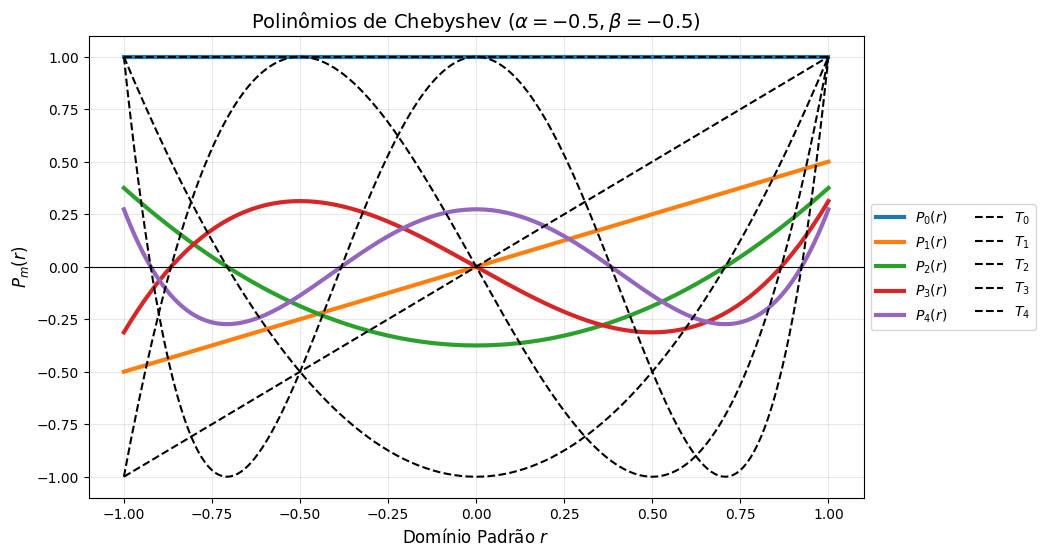

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PAINEL DE CONTROLE DAS FAMÍLIAS DE JACOBI
# ==========================================
# Legendre : alpha = 0.0, beta = 0.0
# Chebyshev: alpha = -0.5, beta = -0.5

# alpha_param = 0.0
# beta_param =  0.0
alpha_param = -0.5
beta_param =  -0.5

# Malha de pontos no domínio padrão [-1, 1]
r_pontos = np.linspace(-1.0, 1.0, 200)
ordem_max = 4

plt.figure(figsize=(10, 6))
for p in range(ordem_max + 1):
    valores_P = [JacobiP(r, p, alpha_param, beta_param) for r in r_pontos]
    plt.plot(r_pontos, valores_P, label=f'$P_{p}(r)$', lw=3)

# Chamando a solucao analitica
if alpha_param == 0.0 and beta_param == 0.0:
  P = Legendre(r_pontos)
  for i in range(5):
      plt.plot(r_pontos, P[i],"--" , color = 'black', label=f"$P_{i}$")

elif alpha_param == -0.5 and beta_param == -0.5:
  T = Chebyshev(r_pontos)
  for i in range(5):
      plt.plot(r_pontos, T[i],"--" , color = 'black', label=f"$T_{i}$")


nome_familia = "Legendre" if alpha_param == 0.0 else "Chebyshev" if alpha_param == -0.5 else "Jacobi Customizado"
plt.title(f"Polinômios de {nome_familia} ($\\alpha={alpha_param}, \\beta={beta_param}$)", fontsize=14)
plt.xlabel("Domínio Padrão $r$", fontsize=12)
plt.ylabel("$P_m(r)$", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, alpha=0.3)
# Colocando a legenda fora, ao lado do gráfico
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)
plt.show()

# ==========================================
# MOMENTO LIVE DEBUGGING:
# 1. Os polinômios de Chebyshev estão de acordo com a literatura?
# ==========================================

#### **SABOOOR CHEBYSHEV?**
<details>
<summary>Clique aqui para entender</summary>

A fórmula de Rodrigues para os polinômios de Jacobi, denotados por $P_k^{(\alpha, \beta)}(\xi)$, impõe uma condição de contorno natural no extremo do domínio $\xi=1$, cujo valor é dado por $\binom{k+\alpha}{k}$ ($\color{blue}{\text{Expressao que "guardamos"}}$)

Quando geramos a família de Legendre usando os parâmetros $\alpha = \beta = 0$, o valor no extremo é simplesmente $\binom{k+0}{k} = 1$. Como o polinômio clássico de Legendre da literatura também é normalizado para valer 1 em $\xi=1$, os resultados obtidos pela fórmula "cravam" perfeitamente sem nenhum ajuste adicional.

Porém, para gerar os polinômios de Chebyshev de primeira espécie, utilizamos os parâmetros $\alpha = \beta = -1/2$. Ao aplicar a fórmula de Rodrigues de Jacobi crua para esses parâmetros, a normalização que sai da equação em $\xi=1$ decai com o grau $k$:$$P_k^{(-1/2, -1/2)}(1) = \binom{k - 1/2}{k} = \frac{\Gamma(k + 1/2)}{k! \sqrt{\pi}}$$

É exatamente esse comportamento de escala que as linhas sólidas do gráfico ($P_k$) estão mostrando:
* Para $k=1$, o valor máximo é $1/2 = 0.5$.
* Para $k=2$, o valor máximo é $3/8 = 0.375$.
* Para $k=3$, o valor máximo é $5/16 = 0.3125$.
* Para $k=4$, o valor máximo é $35/128 \approx 0.2734$.

Para corrigir isso e mapear os resultados para os $T_n(x)$ clássicos de Chebyshev (linhas tracejadas, que preservam a oscilação estrita no intervalo $[-1, 1]$), é preciso multiplicar cada polinômio gerado por um fator de escala que é o inverso daquela normalização.

Matematicamente, o fator multiplicativo para cada grau $n$ é:$$C_k = \frac{k! \sqrt{\pi}}{\Gamma(k + 1/2)}$$

Uma forma muito mais prática de implementar esse fator de correção no script, evitando lidar com a função Gamma para números fracionários, é utilizando fatoriais puros:$$C_k = \frac{2^{2k} (k!)^2}{(2k)!}$$

(**Nota:** para $k=0$, o fator continua sendo $C_0 = 1$, o que bate com o seu $P_0(r) = 1$ no gráfico).Basta multiplicar o seu polinômio final de grau $k$ por $C_k$.

Como observamos, isso não afeta a localização das raízes, apenas redimensiona a amplitude para que os picos e vales encostem perfeitamente em $\pm 1$
</details>

In [ ]:
def coefk(k):
  from math import factorial
  numerador = 2**(2*k) * (factorial(k)**2)
  denominador = factorial(2*k)
  return numerador/denominador

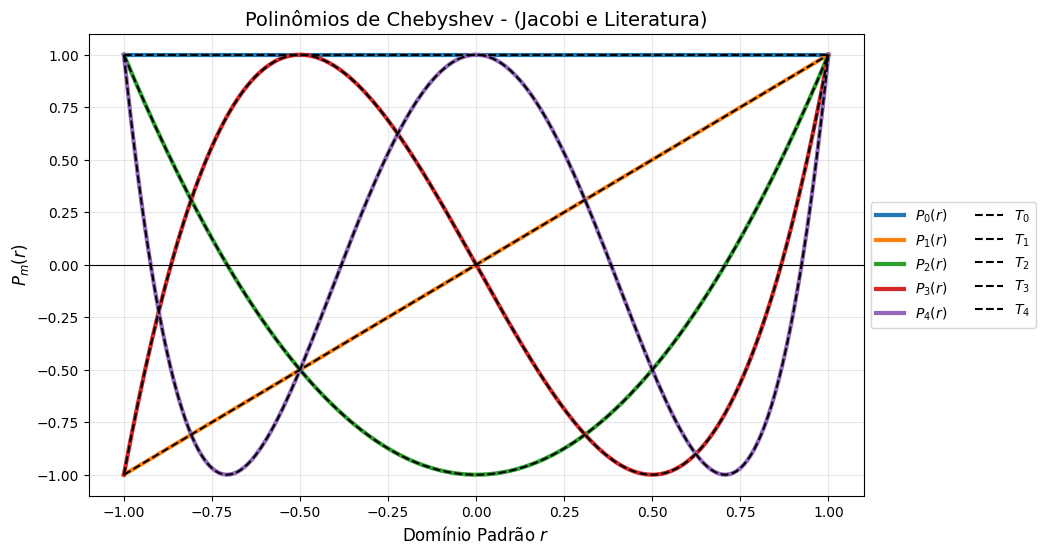

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha_param = -0.5
beta_param =  -0.5

# Malha de pontos no domínio padrão [-1, 1]
r_pontos = np.linspace(-1.0, 1.0, 200)
ordem_max = 4

plt.figure(figsize=(10, 6))
for p in range(ordem_max + 1):
    valores_P = [coefk(p)*JacobiP(r, p, -0.5, -0.5) for r in r_pontos]
    plt.plot(r_pontos, valores_P, label=f'$P_{p}(r)$', lw=3)

# Chamando a solucao analitica
T = Chebyshev(r_pontos)
for i in range(5):
    plt.plot(r_pontos, T[i],"--" , color = 'black', label=f"$T_{i}$")

plt.title("Polinômios de Chebyshev - (Jacobi e Literatura)", fontsize=14)
plt.xlabel("Domínio Padrão $r$", fontsize=12)
plt.ylabel("$P_m(r)$", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, alpha=0.3)
# Colocando a legenda fora, ao lado do gráfico
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)
plt.show()

## 4. Visualizando as Derivadas

Assim como fizemos o comparativo para os Polinômios em si, vamos também observar suas derivadas

**Derivada de Ordem 1 dos Primeiros 5 Polinômios de Legendre**
$$
\begin{array}{|c|c|} \hline
\textbf{Ordem} & \textbf{Derivada} \\
\hline
P_0'(r) & 0 \\[4pt]
P_1'(r) & 1 \\[4pt]
P_2'(r) & 3r \\[4pt]
P_3'(r) & \frac{3}{2}(5r^2-1) \\[4pt]
P_4'(r) & \frac{5}{2}(7r^3-3r) \\ \hline
\end{array}
$$

**Derivada de Ordem 1 dos Primeiros 5 Polinômios de Chebyshev**
$$
\begin{array}{|c|c|} \hline
\textbf{Ordem} & \textbf{Derivada} \\
\hline
T_0'(r) & 0 \\[4pt]
T_1'(r) & 1 \\[4pt]
T_2'(r) & 4r \\[4pt]
T_3'(r) & 12r^2-3 \\[4pt]
T_4'(r) & 32r^3-16r \\ \hline
\end{array}
$$


In [ ]:
import numpy as np
def DLegendre(r):
    dP = [
        np.zeros_like(r),
        np.ones_like(r),
        3*r,
        1.5*(5*r**2 - 1),
        2.5*(7*r**3 - 3*r)
    ]
    return dP

def DChebyshev(r):
    dT = [
        np.zeros_like(r),
        np.ones_like(r),
        4*r,
        12*r**2 - 3,
        32*r**3 - 16*r
    ]
    return dT

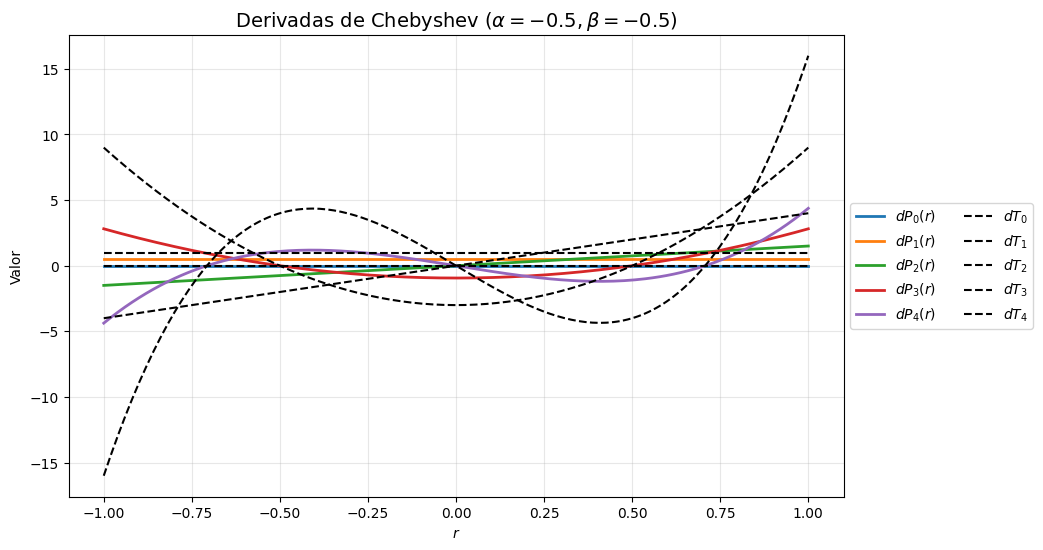

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PAINEL DE CONTROLE DAS FAMÍLIAS DE JACOBI
# ==========================================
# Legendre : alpha = 0.0, beta = 0.0
# Chebyshev: alpha = -0.5, beta = -0.5
# alpha_param = 0.0
# beta_param =  0.0

alpha_param = -0.5
beta_param =  -0.5


# Malha de pontos no domínio padrão [-1, 1]
r_pontos = np.linspace(-1.0, 1.0, 200)
ordem_max = 4

plt.figure(figsize=(10, 6))
for p in range(ordem_max + 1):
    valores_dP = [DJacobiP(r, p, alpha_param, beta_param) for r in r_pontos]
    plt.plot(r_pontos, valores_dP, label=f'$dP_{p}(r)$', lw=2)

# Chamando a solucao analitica
if alpha_param == 0.0 and beta_param == 0.0:
  dP = DLegendre(r_pontos)
  for i in range(5):
    plt.plot(r_pontos, dP[i], "--", color='black', label=f"$dP_{i}$")
elif alpha_param == -0.5 and beta_param == -0.5:
  dT = DChebyshev(r_pontos)
  for i in range(5):
      plt.plot(r_pontos, dT[i],"--" , color = 'black', label=f"$dT_{i}$")


nome_familia = "Legendre" if alpha_param == 0.0 else "Chebyshev" if alpha_param == -0.5 else "Jacobi Customizado"
plt.title(f"Derivadas de {nome_familia} ($\\alpha={alpha_param}, \\beta={beta_param}$)", fontsize=14)
plt.xlabel("$r$")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
# Colocando a legenda fora, ao lado do gráfico
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)
plt.show()

Assim como para os polinômios, as derivadas precisam corrigidas para o caso de Chebyshev, basta usar-mos a função `coefk`

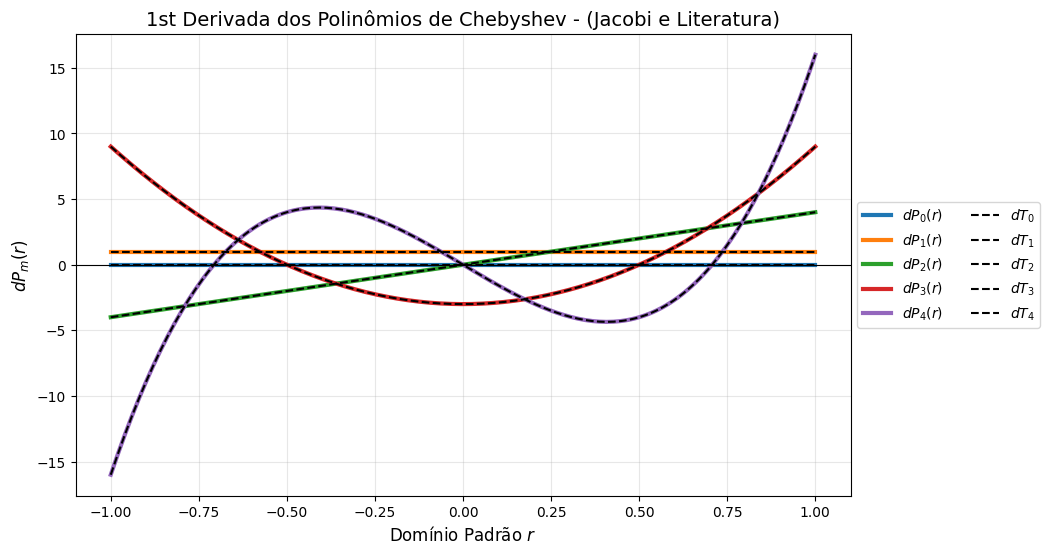

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Malha de pontos no domínio padrão [-1, 1]
r_pontos = np.linspace(-1.0, 1.0, 200)
ordem_max = 4

plt.figure(figsize=(10, 6))
for p in range(ordem_max + 1):
    valores_P = [coefk(p)*DJacobiP(r, p, -0.5, -0.5) for r in r_pontos]
    plt.plot(r_pontos, valores_P, label=f'$dP_{p}(r)$', lw=3)

# Chamando a solucao analitica
dT = DChebyshev(r_pontos)
for i in range(5):
    plt.plot(r_pontos, dT[i],"--" , color = 'black', label=f"$dT_{i}$")

plt.title("1st Derivada dos Polinômios de Chebyshev - (Jacobi e Literatura)", fontsize=14)
plt.xlabel("Domínio Padrão $r$", fontsize=12)
plt.ylabel("$dP_m(r)$", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, alpha=0.3)
# Colocando a legenda fora, ao lado do gráfico
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2)
plt.show()

### Demonstração de $\mathcal{P}_{1}^{\alpha,\beta}(\xi)$

**Demonstração para k=1**  
Primeiro substituimos o valor de k = 1 na expressão (para a derivada ele é omitido por conveniencia)
$$\mathcal{P}_{1}^{\alpha,\beta}(\xi) = \frac{(-1)^1}{2^1 1!}(1-\xi)^{-α}(1+\xi)^{-\beta} \dfrac{d}{d \xi}[(1-\xi)^{\alpha + 1}(1+\xi)^{\beta + 1}]$$
resolvendo a derivada `d(uv) = du*v + u*dv`
$$\dfrac{d}{d \xi}[(1-\xi)^{\alpha + 1}(1+\xi)^{\beta + 1}] = \color{blue}{-(\alpha+1)(1-\xi)^\alpha (1+\xi)^{\beta + 1}} + \color{red}{(1-\xi)^{\alpha + 1}(\beta + 1)(1+\xi)^\beta}$$

fazendo a multiplicação do termo fora da derivada pela parte azul
$$-0.5(1-\xi)^{-α}(1+\xi)^{-\beta} \times (\color{blue}{-(\alpha+1)(1-\xi)^\alpha (1+\xi)^{\beta + 1}}) = 0.5(\alpha+1)(1+\xi) = 0.5 (\alpha + \alpha \xi + \xi + 1)$$

fazendo a multiplicação do termo fora da derivada pela parte vermelha
$$-0.5(1-\xi)^{-α}(1+\xi)^{-\beta} \times (\color{red}{(1-\xi)^{\alpha + 1}(\beta + 1)(1+\xi)^\beta}) = -0.5(\beta+1)(1-\xi) = 0.5(-\beta + \beta \xi + \xi -1)$$

logo, juntando ambos os resultados
$$\begin{align}\mathcal{P}_{1}^{\alpha,\beta}(\xi) = &
0.5 (\alpha + \alpha \xi + \xi + 1) + 0.5(-\beta + \beta \xi + \xi -1)\\
= & 0.5 (\alpha + \alpha \xi + \xi + 1 -\beta + \beta \xi + \xi -1) \\
= & 0.5 (\alpha -\beta + \alpha \xi + \beta \xi + \xi + \xi) \\
= & 0.5 (\alpha -\beta + \alpha \xi + \beta \xi + 2\xi) \\
= & 0.5[\alpha - \beta + (\alpha + \beta + 2) \xi]
\end{align}$$

In [ ]:
def DJacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Primeira derivada do Polinômio de Jacobi de ordem m avaliado no ponto r.
    Utiliza math.gamma para suportar adequadamente os parâmetros fracionários
    (ex: Chebyshev, onde alpha e beta = -0.5).
    """
    if m == 0:
        return 0.0

    # Tratamento especial nas fronteiras do elemento padronizado [-1, 1]
    if r == -1.0:
        c1 = ((-1.0)**(m - 1)) * 0.5 * (alpha + beta + m + 1.0)
        term_num = math.gamma(m + beta + 1.0)
        # math.gamma(n) é equivalente a (n-1)!. Logo, (m-1)! = math.gamma(m)
        term_den = math.gamma(beta + 2.0) * math.gamma(m)
        return c1 * (term_num / term_den)

    if r == 1.0:
        c1 = 0.5 * (alpha + beta + m + 1.0)
        term_num = math.gamma(m + alpha + 1.0)
        term_den = math.gamma(alpha + 2.0) * math.gamma(m)
        return c1 * (term_num / term_den)

    # Para pontos internos, calculamos o polinômio e usamos a relação para a derivada
    pn0 = 1.0
    pn1 = 0.5 * (alpha - beta + (alpha + beta + 2.0) * r)

    if m == 1:
        b1n = (alpha + beta + 2.0) * (1.0 - r**2)
        b2n = 1.0 * (alpha - beta - (alpha + beta + 2.0) * r)
        b3n = 2.0 * (1.0 + alpha) * (1.0 + beta)
        return (1.0 / b1n) * (b2n * pn1 + b3n * pn0)

    # Para m > 1, iteramos a recorrência do polinômio até a ordem m
    for n in range(1, m):
        a1n = 2.0 * (n + 1.0) * (n + alpha + beta + 1.0) * (2.0 * n + alpha + beta)
        a2n = (2.0 * n + alpha + beta + 1.0) * (alpha**2 - beta**2)
        a3n = (2.0 * n + alpha + beta) * (2.0 * n + alpha + beta + 1.0) * (2.0 * n + alpha + beta + 2.0)
        a4n = 2.0 * (n + alpha) * (n + beta) * (2.0 * n + alpha + beta + 2.0)

        pn2 = (1.0 / a1n) * ((a2n + a3n * r) * pn1 - a4n * pn0)
        pn0 = pn1
        pn1 = pn2

    # Após encontrar P_{m-1} (pn0) e P_m (pn1), calculamos a derivada UMA vez
    b1n = (2.0 * m + alpha + beta) * (1.0 - r**2)
    b2n = m * (alpha - beta - (2.0 * m + alpha + beta) * r)
    b3n = 2.0 * (m + alpha) * (m + beta)

    return (1.0 / b1n) * (b2n * pn1 + b3n * pn0)